In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from scipy.spatial import procrustes

import umap

In [10]:
digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
reference_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

reference_model.fit(X_train)

reference_embedding = reference_model.transform(X_test)

c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
rng = np.random.default_rng(42)

sample_sizes = [1.0, 0.9, 0.75, 0.5, 0.25]

disparities = []

for frac in sample_sizes:

    n = int(frac * len(X_train))

    idx = rng.choice(len(X_train), n, replace=False)

    X_subset = X_train[idx]

    model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    model.fit(X_subset)

    test_embedding = model.transform(X_test)

    _, _, disparity = procrustes(
        reference_embedding,
        test_embedding
    )

    disparities.append(disparity)

    print(f"{frac:.0%} training -> disparity = {disparity:.4f}")

c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


100% training -> disparity = 0.1534


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


90% training -> disparity = 0.2028


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


75% training -> disparity = 0.3452


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


50% training -> disparity = 0.2033


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


25% training -> disparity = 0.6719


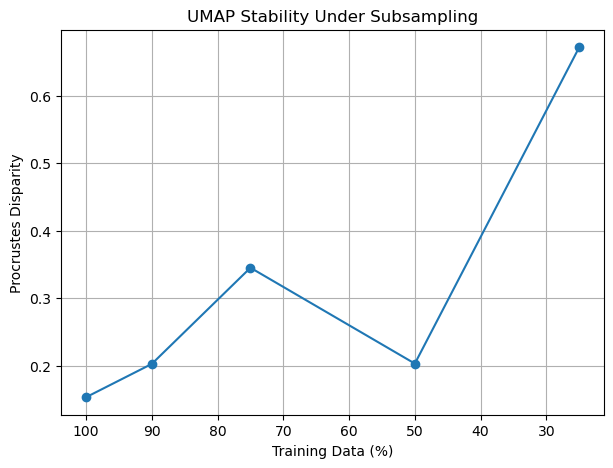

In [13]:
plt.figure(figsize=(7,5))

plt.plot(
    np.array(sample_sizes) * 100,
    disparities,
    marker="o"
)

plt.gca().invert_xaxis()

plt.xlabel("Training Data (%)")
plt.ylabel("Procrustes Disparity")
plt.title("UMAP Stability Under Subsampling")

plt.grid(True)

plt.show()